# Binomial Logistic Regression Project

In this project, I developed a **binomial logistic regression model** to estimate the probability of a binary outcome based on multiple predictor variables. Logistic regression is a fundamental technique in data science that enables flexible, multivariable analysis—providing valuable insights for both predictive modeling and decision-making.

---

## 📌 Objective

To demonstrate proficiency in:

- **Exploratory Data Analysis (EDA)**
- Building and evaluating a **binomial logistic regression model**

---

## 🎯 Goal

To construct a binomial logistic regression model and assess its performance using appropriate evaluation metrics and interpretation of results.

---

## 🔍 Part 1: EDA & Model Assumptions

In this section:

- Performed EDA to explore the dataset structure and understand variable distributions.
- Checked for missing values, outliers, and multicollinearity.
- Reflected on the importance of EDA in preparing data for regression modeling.

**Key Questions:**
- What insights does the initial EDA reveal about the data?
- Are there any variables that need transformation or removal?
- Are the assumptions of logistic regression reasonably met?

---

## ⚙️ Part 2: Model Building & Evaluation

In this section:

- Selected relevant features based on EDA.
- Built a binomial logistic regression model.
- Evaluated model performance using:
  - Accuracy
  - Precision
  - Recall
  - F1-score
  - ROC Curve / AUC

**Key Questions:**
- What resources were most helpful during model construction?
- How well does the model perform on the test data?

---

## 📈 Part 3: Model Interpretation

In this section:

- Interpreted model coefficients to assess variable influence.
- Identified statistically significant predictors.
- Connected statistical findings with domain/business understanding.

**Key Questions:**
- What key insights emerged from the model(s)?
- What business recommendations can be made based on the findings?

## Part 1: EDA & Model Assumptions

### Task 1: Imports and Data Loading
In this step, I imported the necessary libraries and loaded the dataset required to build a binomial logistic regression model. The tools used include packages for data manipulation, visualization, and model development.

In [1]:

# Packages for numerics + dataframes
import pandas as pd
import numpy as np

# Packages for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Packages for Logistic Regression & Confusion Matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_score, \
recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression


Import the dataset.

In [4]:
# Load the dataset by running this cell

# Load dataset into a dataframe
df = pd.read_csv("../Data/waze_dataset.csv")


### 🔍 Task 2: Purpose of EDA Before Building a Logistic Regression Model

Exploratory Data Analysis (EDA) is an essential step in preparing the dataset before fitting a binomial logistic regression model. It allows us to understand the structure of the data and address potential issues that could impact model performance.

**Key purposes of EDA include:**

- **Detecting outliers and extreme values**: These can heavily influence the coefficients in logistic regression. EDA helps define strategies for managing them, such as removing rows, capping extreme values, or replacing them with average values.

- **Identifying and handling missing data**: Through EDA, we can decide whether to exclude rows with missing values or impute them using techniques like mean, median, or mode substitution.

- **Creating new features**: Sometimes, combining existing variables—such as creating ratios or interaction terms—can improve model performance. For example, a `drives_sessions_ratio` variable can be created by dividing the number of drives by the number of sessions.

Overall, EDA helps ensure the dataset is clean, relevant, and suitable for building a robust and interpretable logistic regression model.

### **Task 2a. Explore data with EDA**

Analyze and discover data, looking for correlations, missing data, potential outliers, and/or duplicates.



Start with `shape` and `info()`.

In [5]:
print(df.shape)

df.info()

(14999, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       14999 non-null  int64  
 1   label                    14299 non-null  object 
 2   sessions                 14999 non-null  int64  
 3   drives                   14999 non-null  int64  
 4   total_sessions           14999 non-null  float64
 5   n_days_after_onboarding  14999 non-null  int64  
 6   total_navigations_fav1   14999 non-null  int64  
 7   total_navigations_fav2   14999 non-null  int64  
 8   driven_km_drives         14999 non-null  float64
 9   duration_minutes_drives  14999 non-null  float64
 10  activity_days            14999 non-null  int64  
 11  driving_days             14999 non-null  int64  
 12  device                   14999 non-null  object 
dtypes: float64(3), int64(8), object(2)
memory usage: 1.5+ MB


The `label` column is missing 700 values.

Use `head()`.

In [7]:
df.head()

,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android


We remove the `ID` column from the dataset since it does not contribute any analytical value to our modeling or insights. It is a unique identifier that does not influence the target or features of interest.

In [8]:
df = df.drop('ID', axis=1)

Now, check the class balance of the dependent (target) variable, `label`.

In [9]:
df['label'].value_counts(normalize=True)

label
retained    0.822645
churned     0.177355
Name: proportion, dtype: float64

Call `describe()` on the data.

In [10]:
df.describe()

,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,80.633776,67.281152,189.964447,1749.837789,121.605974,29.672512,4039.340921,1860.976012,15.537102,12.179879
std,80.699065,65.913872,136.405128,1008.513876,148.121544,45.394651,2502.149334,1446.702288,9.004655,7.824036
min,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000
25%,23.000000,20.000000,90.661156,878.000000,9.000000,0.000000,2212.600607,835.996260,8.000000,5.000000
50%,56.000000,48.000000,159.568115,1741.000000,71.000000,9.000000,3493.858085,1478.249859,16.000000,12.000000
75%,112.000000,93.000000,254.192341,2623.500000,178.000000,43.000000,5289.861262,2464.362632,23.000000,19.000000
max,743.000000,596.000000,1216.154633,3500.000000,1236.000000,415.000000,21183.401890,15851.727160,31.000000,30.000000


**Question:** Are there any variables that could potentially have outliers just by assessing the quartile values, standard deviation, and max values?

> **Yes, the following variables appear to have potential outliers:**
>
> - `sessions`  
> - `drives`  
> - `total_sessions`  
> - `total_navigations_fav1`  
> - `total_navigations_fav2`  
> - `driven_km_drives`  
> - `duration_minutes_drives`  
>
> In all of these variables, the maximum values are several standard deviations above the 75th percentile. This pattern suggests the presence of outliers that may need to be addressed depending on the goals of the analysis.


### **Task 2b. Create features**

Create features that may be of interest to the stakeholder and/or that are needed to address the business scenario/problem.

#### **`km_per_driving_day`**

We previously observed a correlation between churn rate and the distance driven per driving day in the last month. To capture this behavior more effectively, we create a new feature:
- `km_per_driving_day`: the average kilometers driven per day with at least one drive.

This feature can help us better understand user behavior and may improve model performance.

In [11]:
# 1. Create `km_per_driving_day` column
df['km_per_driving_day'] = df['driven_km_drives'] / df['driving_days']

# 2. Call `describe()` on the new column
df['km_per_driving_day'].describe()

c:\Users\juche\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    1.499900e+04
mean              inf
std               NaN
min      3.022063e+00
25%      1.672804e+02
50%      3.231459e+02
75%      7.579257e+02
max               inf
Name: km_per_driving_day, dtype: float64

While engineering the `km_per_driving_day` feature, some users had zero driving days, resulting in division by zero. In such cases, pandas assigns a value of `inf` (infinity). Since these represent users who didn't drive at all, we replace `inf` values with `0` to reflect zero average distance per driving day.

In [12]:
# 1. Convert infinite values to zero
df.loc[df['km_per_driving_day']==np.inf, 'km_per_driving_day'] = 0

# 2. Confirm that it worked
df['km_per_driving_day'].describe()

count    14999.000000
mean       578.963113
std       1030.094384
min          0.000000
25%        136.238895
50%        272.889272
75%        558.686918
max      15420.234110
Name: km_per_driving_day, dtype: float64

#### **`professional_driver`**

We create a new binary feature, `professional_driver`, to identify users who are likely to be professional drivers. A user is considered a professional driver if they meet both of the following criteria in the last month:

- Drove **60 or more** times (`drives` ≥ 60)
- Drove on **15 or more** different days (`driving_days` ≥ 15)

> These thresholds are informed by domain knowledge and are intended to distinguish high-frequency drivers from typical users, though they remain arbitrary to some extent.


#### **`professional_driver` (with `np.where`)**

To classify users as professional drivers, we use the `np.where()` function. A user is considered a professional driver if they meet **both** of the following criteria:

- At least **60 drives**
- At least **15 driving days**

The function assigns:
- `1` to users who meet both conditions  
- `0` otherwise


In [13]:
# Create `professional_driver` column
df['professional_driver'] = np.where((df['drives'] >= 60) & (df['driving_days'] >= 15), 1, 0)

#### **Inspecting `professional_driver`**

We now perform a quick inspection of the new feature to understand its distribution and potential relationship with churn:

1. Count how many users are classified as professional drivers vs non-professionals.
2. Calculate the churn rate within each group to explore if professional drivers are more or less likely to churn.


In [14]:
# 1. Check count of professionals and non-professionals
print(df['professional_driver'].value_counts())

# 2. Check in-class churn rate
df.groupby(['professional_driver'])['label'].value_counts(normalize=True)

professional_driver
0    12405
1     2594
Name: count, dtype: int64


professional_driver  label   
0                    retained    0.801202
                     churned     0.198798
1                    retained    0.924437
                     churned     0.075563
Name: proportion, dtype: float64

The churn rate for professional drivers is 7.6%, while the churn rate for non-professionals is 19.9%. This seems like it could add predictive signal to the model.

### **Task 3a. Preparing variables**

Call `info()` on the dataframe to check the data type of the `label` variable and to verify if there are any missing values.

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   label                    14299 non-null  object 
 1   sessions                 14999 non-null  int64  
 2   drives                   14999 non-null  int64  
 3   total_sessions           14999 non-null  float64
 4   n_days_after_onboarding  14999 non-null  int64  
 5   total_navigations_fav1   14999 non-null  int64  
 6   total_navigations_fav2   14999 non-null  int64  
 7   driven_km_drives         14999 non-null  float64
 8   duration_minutes_drives  14999 non-null  float64
 9   activity_days            14999 non-null  int64  
 10  driving_days             14999 non-null  int64  
 11  device                   14999 non-null  object 
 12  km_per_driving_day       14999 non-null  float64
 13  professional_driver      14999 non-null  int64  
dtypes: float64(4), int64(8

#### **Handling Missing Labels**

There are 700 missing values in the `label` column. From earlier EDA, we found no evidence of a non-random cause behind the missingness. Since these missing values represent less than 5% of the dataset, we safely drop these rows to ensure model training is not affected by incomplete labels.


In [16]:
# Drop rows with missing data in `label` column
df = df.dropna(subset=['label'])

#### **Impute Outliers**

Rather than dropping outliers—an approach only appropriate in cases like typographical errors—we opt to **cap** extreme values to reduce their influence.

We previously identified seven variables with likely outliers:

- `sessions`  
- `drives`  
- `total_sessions`  
- `total_navigations_fav1`  
- `total_navigations_fav2`  
- `driven_km_drives`  
- `duration_minutes_drives`

For this analysis, we replace values above the **95th percentile** in each of these columns with the corresponding **95th percentile value**. This is a common and simple approach to mitigating the impact of extreme values.



In [17]:
# Impute outliers
for column in ['sessions', 'drives', 'total_sessions', 'total_navigations_fav1',
               'total_navigations_fav2', 'driven_km_drives', 'duration_minutes_drives']:
    threshold = df[column].quantile(0.95)
    df.loc[df[column] > threshold, column] = threshold

Call `describe()`.

In [18]:
df.describe()

,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,km_per_driving_day,professional_driver
count,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000,14299.000000
mean,76.539688,63.964683,183.717304,1751.822505,114.562767,27.187216,3944.558631,1792.911210,15.544653,12.182530,581.942399,0.173998
std,67.243178,55.127927,118.720520,1008.663834,124.378550,36.715302,2218.358258,1224.329759,9.016088,7.833835,1038.254509,0.379121
min,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000,0.000000,0.000000
25%,23.000000,20.000000,90.457733,878.500000,10.000000,0.000000,2217.319909,840.181344,8.000000,5.000000,136.168003,0.000000
50%,56.000000,48.000000,158.718571,1749.000000,71.000000,9.000000,3496.545617,1479.394387,16.000000,12.000000,273.301012,0.000000
75%,111.000000,93.000000,253.540450,2627.500000,178.000000,43.000000,5299.972162,2466.928876,23.000000,19.000000,558.018761,0.000000
max,243.000000,200.000000,455.439492,3500.000000,422.000000,124.000000,8898.716275,4668.180092,31.000000,30.000000,15420.234110,1.000000


#### **Encode categorical variables**

#### **Convert `label` to Binary for Modeling**

To train a logistic regression model, the target variable must be binary.  
We convert the `label` column as follows:

- `0` for users who were **retained**
- `1` for users who **churned**

We store the result in a new column called `label2` to preserve the original `label` values.


In [19]:
# Create binary `label2` column
df['label2'] = np.where(df['label']=='churned', 1, 0)
df[['label', 'label2']].tail()

,label,label2
14994,retained,0
14995,retained,0
14996,retained,0
14997,churned,1
14998,retained,0


### **Task 3b. Determine whether assumptions have been met**

Before fitting a logistic regression model, it's important to consider whether the data meets the core assumptions of the method:

- **Independent observations**: This relates to how the data was collected.  
  ✅ For this project, we assume that observations are independent.

- **No extreme outliers**:  
  ✅ This assumption has already been addressed through capping at the 95th percentile.

- **Little to no multicollinearity among predictors**:  
  🔄 To be evaluated before modeling, using techniques like correlation matrices or VIF scores.

- **Linear relationship between each predictor (X) and the logit of the outcome (y)**:  
  🔄 This assumption will be assessed after the model is trained.

> **Note:** In real-world settings, modeling assumptions are often imperfectly satisfied. The impact of assumption violations depends on the specific context—some violations may have negligible effects, while others can severely compromise model performance.

#### **Collinearity**

Check the correlation among predictor variables. First, generate a correlation matrix.

In [21]:
# Generate a correlation matrix
df.select_dtypes(include='number').corr(method='pearson')

,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,km_per_driving_day,professional_driver,label2
sessions,1.000000,0.996942,0.597189,0.007101,0.001858,0.008536,0.002996,-0.004545,0.025113,0.020294,-0.011569,0.443654,0.034911
drives,0.996942,1.000000,0.595285,0.006940,0.001058,0.009505,0.003445,-0.003889,0.024357,0.019608,-0.010989,0.444425,0.035865
total_sessions,0.597189,0.595285,1.000000,0.006596,0.000187,0.010371,0.001016,-0.000338,0.015755,0.012953,-0.016167,0.254433,0.024568
n_days_after_onboarding,0.007101,0.006940,0.006596,1.000000,-0.002450,-0.004968,-0.004652,-0.010167,-0.009418,-0.007321,0.011764,0.003770,-0.129263
total_navigations_fav1,0.001858,0.001058,0.000187,-0.002450,1.000000,0.002866,-0.007368,0.005646,0.010902,0.010419,-0.000197,-0.000224,0.052322
total_navigations_fav2,0.008536,0.009505,0.010371,-0.004968,0.002866,1.000000,0.003559,-0.003009,-0.004425,0.002000,0.006751,0.007126,0.015032
driven_km_drives,0.002996,0.003445,0.001016,-0.004652,-0.007368,0.003559,1.000000,0.690515,-0.007441,-0.009549,0.344811,-0.000904,0.019767
duration_minutes_drives,-0.004545,-0.003889,-0.000338,-0.010167,0.005646,-0.003009,0.690515,1.000000,-0.007895,-0.009425,0.239627,-0.012128,0.040407
activity_days,0.025113,0.024357,0.015755,-0.009418,0.010902,-0.004425,-0.007441,-0.007895,1.000000,0.947687,-0.397433,0.453825,-0.303851
driving_days,0.020294,0.019608,0.012953,-0.007321,0.010419,0.002000,-0.009549,-0.009425,0.947687,1.000000,-0.407917,0.469776,-0.294259


Now, plot a correlation heatmap.

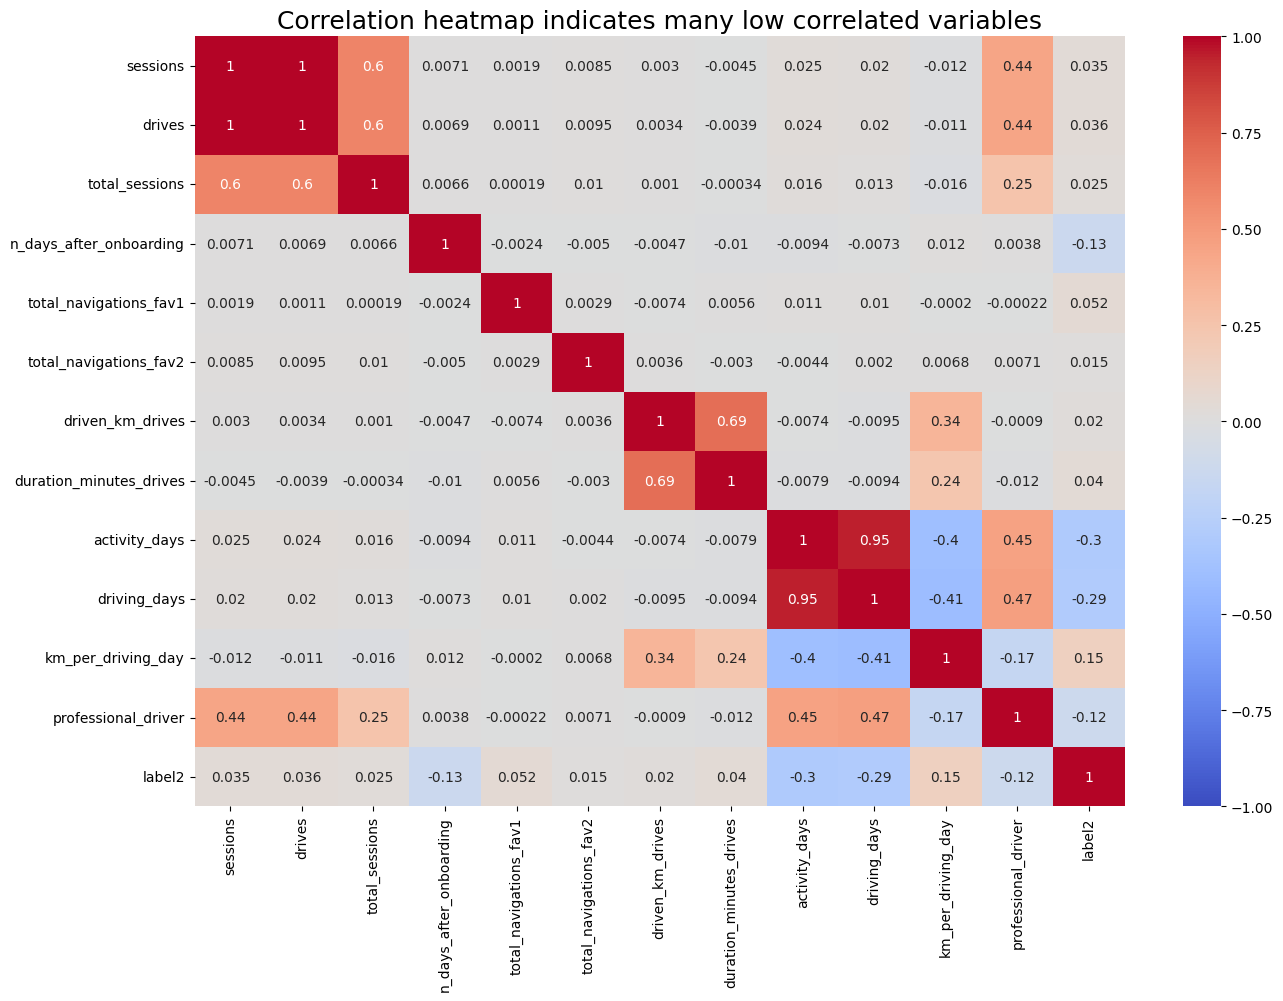

In [24]:
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include='number')

# Plot correlation heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(numeric_df.corr(method='pearson'), vmin=-1, vmax=1, annot=True, cmap='coolwarm')
plt.title('Correlation heatmap indicates many low correlated variables', fontsize=18)
plt.show()


#### **Multicollinearity Check**

A high Pearson correlation coefficient between predictor variables may indicate **multicollinearity**, which can negatively affect the performance and interpretability of regression models.

As a general rule:
- If two variables have a correlation coefficient greater than **|0.7|**, they are considered to be strongly multicollinear.
- In such cases, it's recommended to retain only one of the variables in the model.

> **Note:** The 0.7 threshold is not fixed—some domains may choose 0.6 or 0.8 depending on context.

---

**Question:** Which variables are multicollinear with each other?

> The following pairs show strong multicollinearity:
>
> - `sessions` and `drives`: **1.00**  
> - `driving_days` and `activity_days`: **0.95**

We may consider removing or combining one variable from each pair to reduce redundancy and avoid multicollinearity in the model.


### **Task 3c. Create dummies (if necessary)**

Since `device` is a categorical variable and we plan to include it as a predictor, we need to convert it to a numeric format.

Although libraries like `pd.get_dummies()` or `OneHotEncoder()` are commonly used for categorical encoding, they are best suited for cases with multiple categorical variables or many categories.

In this case, because `device` is the **only** remaining categorical variable and has only two categories, we can encode it directly:

- `Android` → `0`  
- `iPhone` → `1`

We will store the result in a new column called `device2`.

In [25]:
# Create new `device2` variable
df['device2'] = np.where(df['device']=='Android', 0, 1)
df[['device', 'device2']].tail()

,device,device2
14994,iPhone,1
14995,Android,0
14996,iPhone,1
14997,iPhone,1
14998,iPhone,1


### **Task 3d. Model building**

#### **Assign predictor variables and target**

To build the model, we must define the set of predictor variables (`X`) by removing variables that should not be included:

- `label` and `label2`: These are the target variables, so they should be excluded from the predictors.
- `device`: This is the original categorical version; we've already created a binary version (`device2`).
- `sessions` and `driving_days`: These are highly multicollinear with other variables, and in each case, we retained the variable that showed a stronger correlation with the target.

> We retain `drives` and `activity_days` instead of `sessions` and `driving_days` because they had slightly stronger correlations with `label2`.

In [26]:
# Isolate predictor variables
X = df.drop(columns = ['label', 'label2', 'device', 'sessions', 'driving_days'])

The binary target variable for our logistic regression model is `label2`, which indicates whether a user churned (`1`) or was retained (`0`).

We isolate this column and assign it to the variable `y`.

In [28]:
# Isolate target variable
y = df['label2']

#### **Split the data**

To evaluate the model fairly and avoid data leakage, we split our dataset into **training** and **testing** sets.

Because the target class is **imbalanced** (82% retained vs. 18% churned), we use the `stratify` parameter to ensure that both classes are proportionally represented in both the training and test sets.

This helps maintain class balance and prevents biased performance estimates.

In [29]:
# Perform the train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

In [30]:
# Use .head()
X_train.head()

,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,km_per_driving_day,professional_driver,device2
152,108,186.192746,3116,243,124,8898.716275,4668.180092,24,612.305861,1,1
11899,2,3.487590,794,114,18,3286.545691,1780.902733,5,3286.545691,0,1
10937,139,347.106403,331,4,7,7400.838975,2349.305267,15,616.736581,0,0
669,108,455.439492,2320,11,4,6566.424830,4558.459870,18,410.401552,1,1
8406,10,89.475821,2478,135,0,1271.248661,938.711572,27,74.779333,0,1


We now instantiate and train a **logistic regression model** using scikit-learn.

Because our predictors are **not scaled**, we set `penalty='none'` to disable regularization. Regularization (like L2 or L1) can disproportionately affect unscaled features and distort model performance.

We then fit the model using the training data (`X_train`, `y_train`).

In [38]:
model = LogisticRegression(penalty=None, solver='lbfgs', max_iter=400)
model.fit(X_train, y_train)

c:\Users\juche\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 400 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=400).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,400
,multi_class,'deprecated'


To understand how each feature influences the model, we examine the **coefficients**.

- You can access them using the `.coef_` attribute of the fitted logistic regression model.
- These coefficients represent the change in **log-odds** of the target variable (`label2`) for every **one-unit increase** in the corresponding feature.
- The order of coefficients matches the order of columns in `X_train`.

For clarity, we create a `pandas.Series` that maps each column name to its coefficient value.

In [39]:
pd.Series(model.coef_[0], index=X.columns)

drives                     0.001939
total_sessions             0.000359
n_days_after_onboarding   -0.000401
total_navigations_fav1     0.001252
total_navigations_fav2     0.000990
driven_km_drives          -0.000013
duration_minutes_drives    0.000110
activity_days             -0.105324
km_per_driving_day         0.000019
professional_driver       -0.007516
device2                    0.022953
dtype: float64

Call the model's `intercept_` attribute to get the intercept of the model.

In [40]:
model.intercept_

array([-0.05783024])

#### **Check Final Assumption: Linearity between X and Logit**

To check the last assumption of logistic regression, we verify the **linear relationship** between each predictor and the **logit** (log-odds) of the target.

- First, use the model's `predict_proba()` method to get the **estimated probability of churn** for each sample in the **training set**.
- The output is a 2D array:  
  - Column 0: Probability of the class `0` (`retained`)  
  - Column 1: Probability of the class `1` (`churned`)
- We will keep only the second column (probability of churn).


In [41]:
# Get the predicted probabilities of the training data
training_probabilities = model.predict_proba(X_train)
training_probabilities

array([[0.93743372, 0.06256628],
       [0.62186909, 0.37813091],
       [0.76667965, 0.23332035],
       ...,
       [0.91809383, 0.08190617],
       [0.84886622, 0.15113378],
       [0.93336406, 0.06663594]], shape=(10724, 2))

In logistic regression, the relationship between a predictor and the **logit** (log-odds) of the response should be **linear**.

The logit function is defined as:

$$
logit(p) = ln(\frac{p}{1-p})
$$

We will now:

1. Create a copy of the original dataframe `df` and name it `logit_data`.
2. Add a new column called `logit` that stores the logit transformation of each user's **predicted probability of churn** from the training set.


In [42]:
# 1. Copy the `X_train` dataframe and assign to `logit_data`
logit_data = X_train.copy()

# 2. Create a new `logit` column in the `logit_data` df
logit_data['logit'] = [np.log(prob[1] / prob[0]) for prob in training_probabilities]

Plot a regression plot where the x-axis represents an independent variable and the y-axis represents the log-odds of the predicted probabilities.

In a comprehensive analysis, this kind of plot would be generated for each continuous or discrete predictor variable. For demonstration purposes, we will show the plot for `activity_days` only.

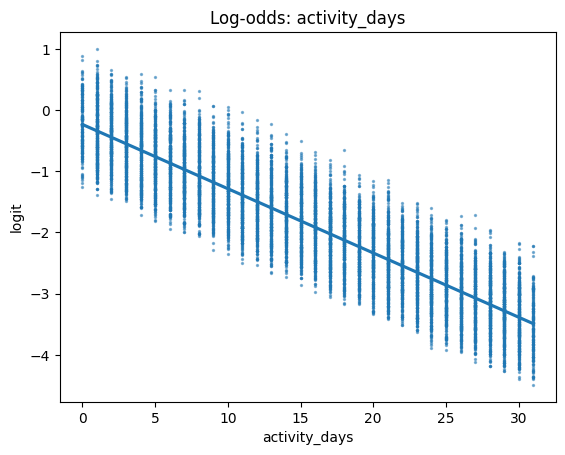

In [43]:
# Plot regplot of `activity_days` log-odds
sns.regplot(x='activity_days', y='logit', data=logit_data, scatter_kws={'s': 2, 'alpha': 0.5})
plt.title('Log-odds: activity_days');

### **Task 4a. Results and evaluation**

If the assumptions of logistic regression are satisfied, the results of the model can be appropriately interpreted.

Use the code block below to generate predictions for the test data.


In [44]:
# Generate predictions on X_test
y_preds = model.predict(X_test)

Now, use the `.score()` method on the model, passing `X_test` and `y_test` as arguments. By default, the score returned by scikit-learn’s logistic regression is **accuracy**.

What is the accuracy of your model?

> *Consider:* Is accuracy the most appropriate metric to evaluate this model, especially given the class imbalance?

In [45]:
# Score the model (accuracy) on the test data
model.score(X_test, y_test)

0.8243356643356643

### **Task 4b. Show results with a confusion matrix**

Use scikit-learn’s `confusion_matrix` function to compute the confusion matrix for your model. Pass `y_test` (true labels) and `y_preds` (predicted labels) as arguments.

This will help you understand how many observations were correctly and incorrectly classified across both classes.

In [46]:
cm = confusion_matrix(y_test, y_preds)

Next, use the `ConfusionMatrixDisplay()` function from scikit-learn to visualize the confusion matrix.

Pass the confusion matrix you created in the previous step as the `confusion_matrix` argument, and call `.plot()` to display it.

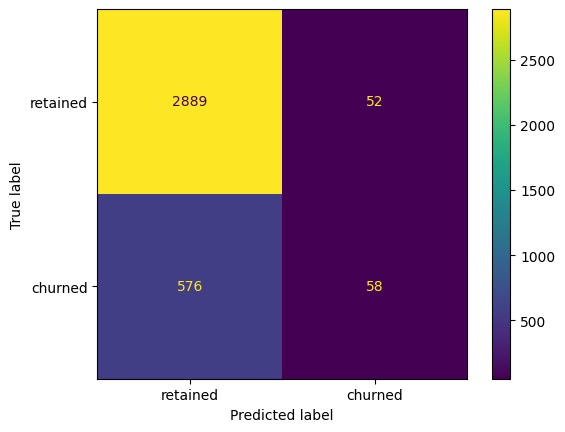

In [47]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=['retained', 'churned'],
                              )
disp.plot();

You can compute precision and recall manually using the confusion matrix.

Alternatively, use scikit-learn's [`classification_report()`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) function to generate a summary table of evaluation metrics.  
Call this function using `y_test` and `y_preds` as arguments.

In [48]:
# Calculate precision manually
precision = cm[1,1] / (cm[0, 1] + cm[1, 1])
precision

np.float64(0.5272727272727272)

In [49]:
# Calculate recall manually
recall = cm[1,1] / (cm[1, 0] + cm[1, 1])
recall

np.float64(0.0914826498422713)

In [50]:
# Create a classification report
target_labels = ['retained', 'churned']
print(classification_report(y_test, y_preds, target_names=target_labels))

              precision    recall  f1-score   support

    retained       0.83      0.98      0.90      2941
     churned       0.53      0.09      0.16       634

    accuracy                           0.82      3575
   macro avg       0.68      0.54      0.53      3575
weighted avg       0.78      0.82      0.77      3575



**Note:** The model demonstrates mediocre precision and very low recall.  
This indicates that it produces a high number of false negatives and fails to correctly identify many users who are likely to churn.

Generate a bar graph of the model's coefficients for a visual representation of the importance of the model's features.

In [51]:
# Create a list of (column_name, coefficient) tuples
feature_importance = list(zip(X_train.columns, model.coef_[0]))

# Sort the list by coefficient value
feature_importance = sorted(feature_importance, key=lambda x: x[1], reverse=True)
feature_importance

[('device2', np.float64(0.02295327264297081)),
 ('drives', np.float64(0.0019390476809154028)),
 ('total_navigations_fav1', np.float64(0.001252297818371307)),
 ('total_navigations_fav2', np.float64(0.000990029095082478)),
 ('total_sessions', np.float64(0.00035914947515557397)),
 ('duration_minutes_drives', np.float64(0.00011000249291115778)),
 ('km_per_driving_day', np.float64(1.9318493168478034e-05)),
 ('driven_km_drives', np.float64(-1.2918436920808624e-05)),
 ('n_days_after_onboarding', np.float64(-0.00040131464765642366)),
 ('professional_driver', np.float64(-0.007516378686510085)),
 ('activity_days', np.float64(-0.10532386421421268))]

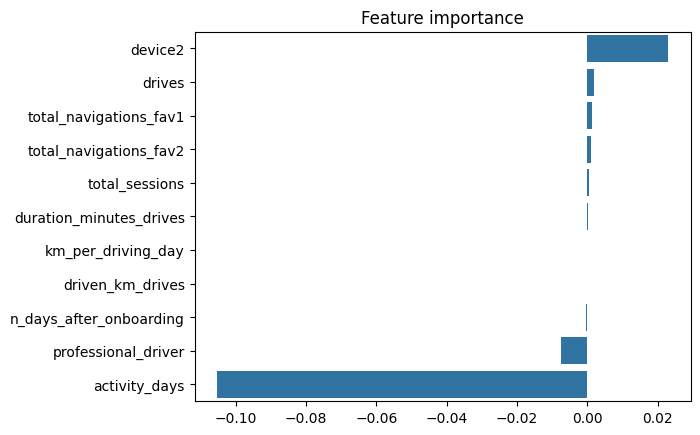

In [52]:
# Plot the feature importances
import seaborn as sns
sns.barplot(x=[x[1] for x in feature_importance],
            y=[x[0] for x in feature_importance],
            orient='h')
plt.title('Feature importance');

### **Task 4c. Conclusion**

The logistic regression model aimed to predict user churn among Waze users. While the model offered some insights, its performance was limited. Below are the main takeaways from the analysis:

---

#### 1. Most Influential Variable
- **Variable:** `activity_days`
- **Impact:** Strong negative correlation with user churn. 
- **Interpretation:** The more days a user was active on the app, the less likely they were to churn.
- **Surprise Level:** Not surprising. This variable was highly correlated with `driving_days`, which was already known to reduce churn based on prior EDA.

---

#### 2. Unexpectedly Weak Predictors
- **Variable:** `km_per_driving_day`
- **Expectation vs. Reality:** While earlier EDA suggested a positive relationship with churn, it ended up being the second-least-important predictor in the model.

---

#### 3. Why Some Variables Underperformed
- **Explanation:** In multivariate models, interactions between predictors can obscure individual effects. While a feature may be predictive in isolation, its impact can diminish when combined with correlated variables. This complexity enhances model accuracy but reduces interpretability.

---

#### 4. Should Waze Use This Model?
- **Recommendation:** Use with caution.
  - ❌ **Not Recommended** for high-stakes business decisions due to **poor recall** (fails to flag many churners).
  - ✅ **Recommended** as a starting point for **further exploration** or to guide feature development.

---

#### 5. Model Improvement Opportunities
- **Feature Engineering:** Create new variables using domain expertise to enhance predictive power.
- **Variable Scaling:** Could help improve model performance, especially for algorithms sensitive to magnitude.
- **Feature Selection:** Eliminate noisy or redundant predictors that dilute model strength.

---

#### 6. Desired Additional Data
- **Drive-Level Details:** Start and end times, geographic patterns, route consistency.
- **In-App Behavior:** Frequency of user interactions (e.g., confirming road hazards).
- **Location Diversity:** Monthly number of unique destinations or origin points.

---

While the current model has limited predictive strength, it reveals important user behavior patterns and lays the groundwork for building more robust churn prediction tools in the future.